# 환경설정

In [2]:
# Colab에는 TensorFlow가 기본 설치되어 있습니다.
import sys
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns

# 운영체제가 macOS('darwin')가 아닐 경우 (예: 구글 코랩 등 리눅스 환경),
# 한글 출력을 위한 나눔 폰트를 설치하고 폰트 캐시를 초기화합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

# 나눔 폰트 파일 시스템 경로를 순회하며 matplotlib 폰트 관리자에 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# matplotlib 및 seaborn의 기본 설정을 변경합니다 (한글 깨짐 방지, 마이너스 부호 깨짐 방지, 고해상도 설정)
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

# 라이브러리 불러오기

In [3]:
# torch: PyTorch의 최상위 베이스 라이브러리
# - 다차원 배열 데이터 구조인 '텐서(Tensor)'를 생성하고 관리하는 핵심 엔진입니다.
# - CPU 및 GPU(CUDA)를 활용하여 인공지능 연산을 빠르게 가속해 줍니다.
import torch

# torch.nn (Neural Network): 신경망 구조를 설계하기 위한 필수 모듈
# - nn.Linear(선형 레이어), nn.Flatten(차원 변환) 등 모델의 뼈대를 만듭니다.
# - nn.BatchNorm1d(배치 정규화), nn.Dropout(드롭아웃) 등 과적합 방지 레이어가 담겨 있습니다.
# - nn.CrossEntropyLoss 처럼 예측 오차를 구하는 다양한 손실 함수(Loss)도 제공합니다.
import torch.nn as nn

# torch.optim (Optimizer): 모델의 가중치(Weight)를 갱신하는 최적화 알고리즘 모듈
# - 오차역전파로 계산된 기울기(Gradient)를 바탕으로 모델을 학습시킵니다
# - 방향성 제어(Momentum)와 가중치별 학습률 조절(RMSProp)이 결합된 Adam이 포함되어 있습니다.
import torch.optim as optim

# torch.nn.init: 레이어들의 가중치 초기값(Initial Value)을 설정하는 모듈
# - 학습 초기 단계에서 데이터 분포가 깨지거나 한쪽으로 뭉치지 않도록 잡아줍니다.
# - ReLU 활성화 함수를 쓸 때 효율이 극대화되는 'He 초기화(kaiming_normal_)'를 적용할 때 씁니다
import torch.nn.init as init

# DataLoader: 학습 데이터를 가공하여 모델에 효율적으로 공급하는 트럭 역할의 유틸리티
# - 데이터를 지정한 크기(batch_size=64)로 쪼개서 공급하는 '미니 배치(Mini-batch)'를 구현합니다.
# - 데이터를 편향 없이 골고루 배우도록 매 에포크마다 무작위로 순서를 섞는(shuffle) 기능도 담당합니다.
from torch.utils.data import DataLoader


# ==============================================================================
# [PyTorch 컴퓨터 비전 전용 라이브러리 (Torchvision)]
# ==============================================================================

# torchvision: 이미지 및 비디오 처리(Computer Vision)에 특화된 독립 패키지
# - 이번 예제에서 사용한 Fashion MNIST를 포함해 AI 연구에 쓰이는 검증된 데이터셋들을 즉시 다운로드해 줍니다.
import torchvision

# torchvision.transforms: 이미지 데이터를 모델이 이해할 수 있게 가공하는 전처리 도구 상자
# - ToTensor(): 일반 이미지 파일(0~255)을 PyTorch가 계산 가능한 텐서(0.0~1.0 범위의 float32)로 바꿉니다.
# - Normalize(): 데이터의 평균과 표준편차를 맞춰주어 학습의 안정성과 배치 정규화 효과를 높입니다.
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

# 0. 디바이스 설정 (연산 장치 결정)
# GPU(CUDA)가 사용 가능한 환경이면 GPU를 사용하고, 그렇지 않으면 CPU를 기본 연산 장치로 설정합니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 데이터셋 불러오기 및 전처리

In [4]:
# ==========================================
# 1. 데이터셋 로드 및 전처리
# ==========================================
# 이미지를 텐서 형태로 바꾸고, 모델이 학습하기 좋은 분포로 정규화(Normalization)하는 파이프라인입니다.
transform = transforms.Compose([
    transforms.ToTensor(),               # 0~255 사이의 픽셀 값을 0.0~1.0 사이의 float32 텐서로 변환합니다.
    transforms.Normalize((0.5,), (0.5,)) # 평균 0.5, 표준편차 0.5를 기준으로 정규화하여 데이터를 -1.0~1.0 범위로 맞춥니다.
])

# torchvision을 이용해 대중적인 Fashion MNIST 데이터셋을 자동으로 다운로드하고 전처리를 적용합니다.
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# 학습 속도 문제를 해결하기 위한 미니 배치(Mini-batch) 설정
# 전체 데이터를 한 번에 학습(Full-batch)하면 계산량이 너무 많아 속도가 급격히 느려집니다
# 따라서 데이터를 64개씩 쪼개어 가중치를 자주 업데이트하는 확률적 경사하강법(SGD) 계열의 방식을 취합니다
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)  # 학습 데이터는 골고루 배우도록 매 에포크마다 섞어줍니다(shuffle=True).
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False) # 평가 데이터는 정답 순서가 유지되어야 하므로 섞지 않습니다.

# Fashion MNIST의 고유 라벨(0~9)을 사람이 읽을 수 있는 텍스트 문자열로 변환하기 위한 리스트입니다.
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']




# MyMLP 모델 만들기
- 오늘 수업의 핵심

In [6]:
# ==========================================
# 2. myMLP 모델 정의 (다층 퍼셉트론 신경망)
# ==========================================
class myMLP(nn.Module):
  def __init__(self):
    super(myMLP, self).__init__()

    # nn.Sequential은 여러 레이어를 순차적으로 쌓아 직관적인 데이터 흐름을 만들어주는 컨테이너입니다.
    self.mlp = nn.Sequential(
      # [차원 변환] Fashion MNIST 이미지는 28x28 해상도를 가집니다.
      # MLP는 1차원 벡터만 입력받을 수 있으므로 28x28을 일렬로 쭉 펼쳐서 784개의 피처로 변환합니다.
      nn.Flatten(),

      # ----------------------------------
      # 은닉층 1 (Hidden Layer 1)
      # ----------------------------------
      nn.Linear(784, 512),     # 입력 피처 784개를 받아 512개의 특징으로 확장하는 선형(Fully Connected) 레이어입니다.

      # 배치 정규화(Batch Normalization)
      # 각 레이어의 입력 분포를 일정하게 맞춰주어 가중치 초기값에 크게 의존하지 않게 만듭니다
      # 궁극적으로 과적합을 억제하고 '학습 속도를 대폭 향상'시킵니다
      nn.BatchNorm1d(512),

      # ReLU 활성화 함수
      # 기존 Sigmoid/Tanh 함수는 깊은 망에서 기울기가 0에 수렴하는 '기울기 소실(Vanishing Gradient)' 문제를 야기합니다.
      # ReLU는 입력이 양수일 때 미분값이 항상 1이므로, 깊은 레이어에서도 오차를 소실 없이 전파합니다.
      nn.ReLU(),

      # 드롭아웃(Dropout)
      # 학습 도중 매 스텝마다 30%의 뉴런을 임의로 꺼버려서(신호 차단),
      # 특정 뉴런에 과도하게 의존하는 '과적합(Overfitting)'을 방지합니다
      nn.Dropout(0.3),


      # ----------------------------------
      # 은닉층 2 (Hidden Layer 2)
      # ----------------------------------
      nn.Linear(512, 256),     # 512개의 특징을 다시 256개로 압축 및 정제합니다.
      nn.BatchNorm1d(256),     # 은닉층 2에도 배치 정규화를 적용하여 학습을 안정화합니다.
      nn.ReLU(),               # 은닉층 2의 비선형성 표현을 위한 ReLU 함수입니다.
      nn.Dropout(0.3),         # 은닉층 2에서도 30% 드롭아웃을 적용해 모델의 복잡도를 제어합니다.

      # ----------------------------------
      # 출력층 (Output Layer)
      # ----------------------------------
      nn.Linear(256, 10)       # 최종적으로 10개의 패션 아이템 클래스에 대한 로짓(Logit) 점수를 출력합니다.
    )

    #.가중치 초기화 적용 (Weight Initialization).
    self._init_weights()

  def _init_weights(self):
    # 모델 내부의 모든 서브 모듈을 돌며 선형 레이어(nn.Linear)를 찾아 초기화 알고리즘을 수행합니다.
    for m in self.modules():
      if isinstance(m, nn.Linear):
        # He 초기화 (Kaiming Normal)
        # 기존의 표준정규분포 초기화는 레이어가 깊어질수록 출력 값을 0으로 수렴하게 만드는 문제가 있습니다
        # He 초기화는 입력 개수 절반의 제곱근을 고려하여 가중치를 채우므로, ReLU 함수와 결합했을 때 가장 안정적이고 효율적인 학습을 보장합니다
        init.kaiming_normal_(m.weight, nonlinearity='relu')

        # 편향(Bias) 값은 학습 초기 편향을 주지 않기 위해 모두 0으로 안전하게 채워둡니다.
        if m.bias is not None:
          init.constant_(m.bias, 0)

  def forward(self, x):
    # 정의된 mlp Sequential 흐름에 따라 순전파(Forward Propagation)를 수행합니다.
    return self.mlp(x)

# 생성한 myMLP 모델 인스턴스를 지정한 연산 장치(CPU 혹은 GPU)로 전송합니다.
model = myMLP().to(device)
model

myMLP(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=10, bias=True)
  )
)

# 손실함수 및 최적화 알고리즘

In [7]:
# ==========================================
# 3. 손실 함수 및 최적화 알고리즘 설정
# ==========================================
# 다중 클래스 분류 문제의 표준 손실 함수인 교차 엔트로피(Cross Entropy)를 정의합니다. (내부에 Softmax 함수가 내장되어 있음)
criterion = nn.CrossEntropyLoss()

# [강의 반영] 가장 발전된 최적화 알고리즘인 Adam 사용
# SGD는 방향 전환 시 진동이 심하고 가중치 업데이트가 비효율적입니다
# Adam은 과거 기울기 방향의 관성을 이용하는 'Momentum'의 장점과, 가중치 변화량에 따라 학습률을 튜닝하는 'RMSProp'의 장점을 결합한 최적의 도구입니다
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 모델 학습

In [8]:
# ==========================================
# 4. 모델 학습 (Training Loop)
# ==========================================

epochs = 5
print("myMLP 모델 학습을 시작합니다...")

# 모델을 학습 모드로 명시적 전환합니다. (이때 Dropout 활성화, BatchNorm은 배치 단위 평균/분산 계산 시작)
model.train()

for epoch in range(epochs):
  running_loss = 0.0
  # 전체 데이터셋을 미니 배치 크기(64개) 단위로 나누어 가져옵니다
  for images, labels in train_loader:
    # 데이터를 모델이 있는 장치(CPU/GPU)로 보냅니다.
    images, labels = images.to(device), labels.to(device)

    # 1) 이전 미니 배치에서 계산되어 남아있던 가중치들의 기울기(Gradient)를 0으로 초기화합니다.
    optimizer.zero_grad()

    # 2) 이미지를 모델에 통과시켜 예측값(Outputs)을 구하는 순전파를 진행합니다.
    outputs = model(images)

    # 3) 예측값과 실제 정답(Labels) 간의 오차를 계산합니다.
    loss = criterion(outputs, labels)

    # 4) 오차를 바탕으로 역전파(Backpropagation)를 수행하여 가중치들의 기울기를 계산합니다
    loss.backward()

    # 5) 계산된 기울기와 Adam 알고리즘 규칙에 따라 모델의 가중치들을 실제로 업데이트(갱신)합니다
    optimizer.step()

    # 에포크 전체 손실값을 구하기 위해 현재 미니 배치의 손실(평균값)에 배치 크기를 곱해 누적합니다.
    running_loss += loss.item() * images.size(0)

  # 에포크 종료 후 전체 데이터 개수로 나누어 평균 손실을 산출하고 출력합니다.
  epoch_loss = running_loss / len(train_loader.dataset)
  print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")


myMLP 모델 학습을 시작합니다...
Epoch [1/5], Loss: 0.5092
Epoch [2/5], Loss: 0.3881
Epoch [3/5], Loss: 0.3536
Epoch [4/5], Loss: 0.3341
Epoch [5/5], Loss: 0.3123


# 모델 평가

In [10]:
# ==========================================
# 5. 모델 평가 및 평가지표(Metrics) 구현
# ==========================================
# 모델을 평가 모드로 전환합니다. (중요: Dropout이 비활성화되며, BatchNorm은 고정된 학습 데이터 통계치를 사용함)
model.eval()

all_preds = []
all_labels = []
all_images = []

# 평가 단계에서는 역전파를 위한 기울기 계산(Gradient Tracking)이 불필요하므로 차단하여 메모리를 절약하고 속도를 높입니다.
with torch.no_grad():
  for images, labels in test_loader:
    images_dev, labels_dev = images.to(device), labels.to(device)

    # 모델의 예측 결과를 가져옵니다.
    outputs = model(images_dev)

    # 10개의 출력 로짓 중 가장 높은 점수(확률)를 가진 인덱스 번호를 최종 예측 클래스로 채택합니다.
    _, preds = torch.max(outputs, 1)

    # 나중에 분석 및 시각화를 하기 위해 넘파이 배열 형태로 정답, 예측값, 원본 이미지를 차곡차곡 누적합니다.
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())
    all_images.extend(images.numpy())

# 리스트를 다루기 편한 NumPy 배열로 최종 변환합니다.
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_images = np.array(all_images)

# 평가지표 산출 및 출력
print("\n=== 모델 최종 평가 지표 ===")
# 전체 데이터 중 올바르게 분류한 비율을 나타내는 Accuracy(정확도)를 계산합니다.
print(f"전체 Accuracy (정확도): {accuracy_score(all_labels, all_preds):.4f}")
print("\n[상세 분류 리포트 (Precision, Recall, F1-Score)]")
# 클래스별 정밀도(Precision), 재현율(Recall), F1-스코어를 상세하게 보여주는 스킬런 리포트입니다.
print(classification_report(all_labels, all_preds, target_names=class_names))


=== 모델 최종 평가 지표 ===
전체 Accuracy (정확도): 0.8828

[상세 분류 리포트 (Precision, Recall, F1-Score)]
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.81      0.84      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.81      0.79      0.80      1000
       Dress       0.88      0.88      0.88      1000
        Coat       0.77      0.86      0.81      1000
      Sandal       0.99      0.91      0.95      1000
       Shirt       0.72      0.70      0.71      1000
     Sneaker       0.89      0.98      0.93      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.96      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



# 테스트

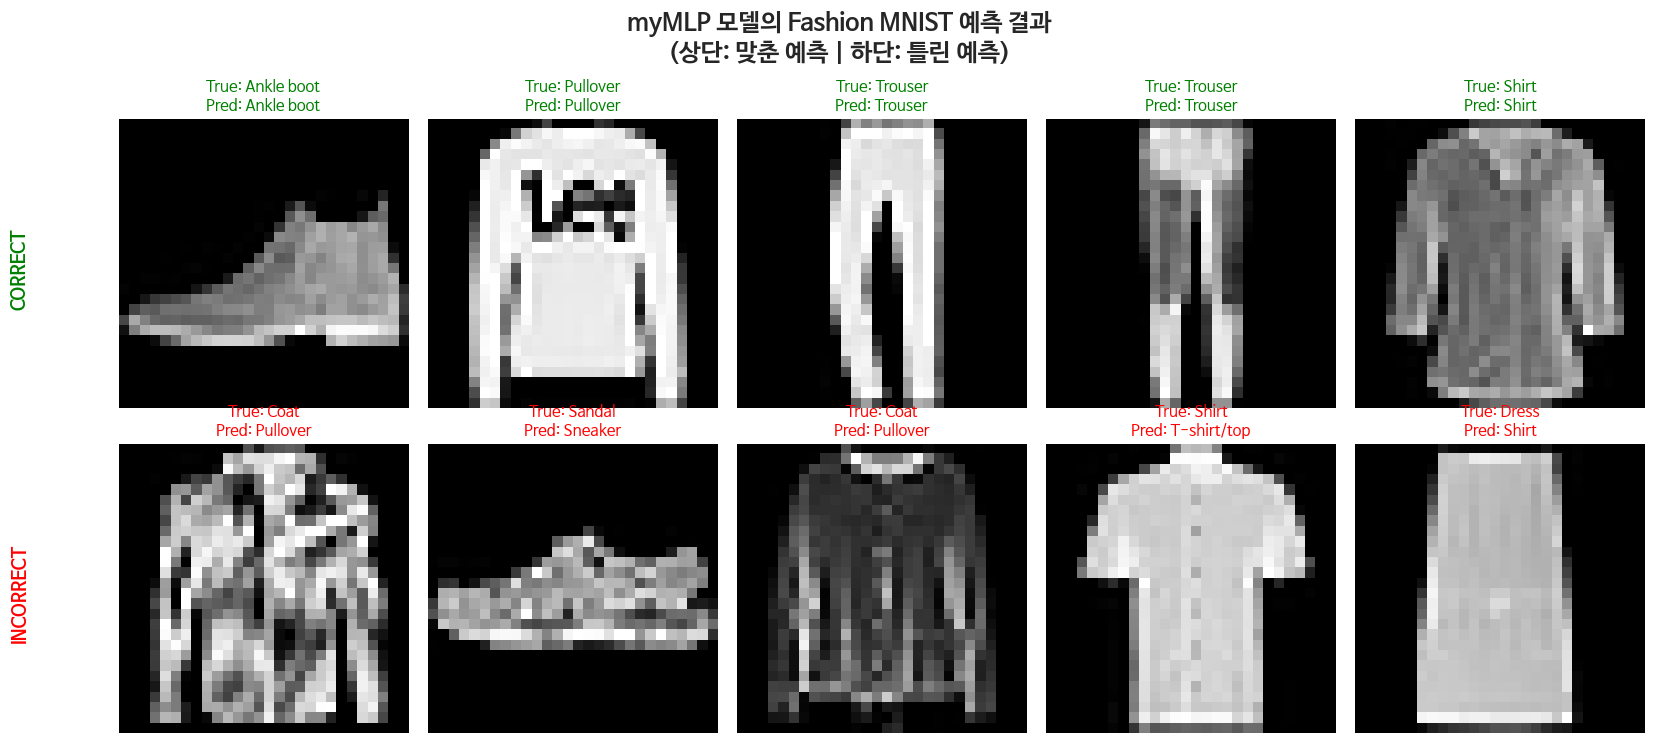

In [11]:
# ==========================================
# 6. fig, ax를 이용한 맞춘 것과 틀린 것 구분 시각화
# ==========================================
# 정답과 예측값이 똑같은 인덱스(맞춘 샘플)와 서로 다른 인덱스(틀린 샘플)를 넘파이 조건문으로 완벽히 분리합니다.
correct_indices = np.where(all_preds == all_labels)[0]
incorrect_indices = np.where(all_preds != all_labels)[0]

# 객체지향형 시각화를 위해 matplotlib의 fig와 axes(2행 5열 서브플롯 배열) 객체를 생성합니다.
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

# 전체 대제목 설정
fig.suptitle("myMLP 모델의 Fashion MNIST 예측 결과\n(상단: 맞춘 예측 | 하단: 틀린 예측)", fontsize=16, fontweight='bold')

# ----------------------------------
# 1층 (첫 번째 행): 성공적으로 맞춘 예측 (Correct) 5개 그리기
# ----------------------------------
for i in range(5):
    ax = axes[0, i]             # 0번째 행의 i번째 열 축을 선택합니다.
    idx = correct_indices[i]    # 맞춘 샘플들 중 앞에서부터 하나씩 인덱스를 가져옵니다.
    img = all_images[idx].squeeze() # (1, 28, 28) 형태의 채널 차원을 없애 2D 이미지 (28, 28)로 만듭니다.

    ax.imshow(img, cmap='gray') # 흑백 이미지 스타일로 플롯에 띄웁니다.
    # 상단 서브플롯 제목을 초록색(green)으로 설정하여 성공을 가시화합니다.
    ax.set_title(f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]}", color='green', fontsize=10)
    ax.axis('off')              # 눈금선과 축 수치를 지워 깔끔하게 이미지 만 보여줍니다.

    # 첫 번째 열의 이미지 왼쪽에 행을 대표하는 라벨 텍스트를 세로로 삽입합니다.
    if i == 0:
        ax.text(-10, 14, "CORRECT", va='center', ha='center', rotation='vertical', fontsize=12, fontweight='bold', color='green')

# ----------------------------------
# 2층 (두 번째 행): 아쉽게 틀린 예측 (Incorrect) 5개 그리기
# ----------------------------------
for i in range(5):
    ax = axes[1, i]             # 1번째 행의 i번째 열 축을 선택합니다.
    idx = incorrect_indices[i]  # 틀린 샘플들 중 앞에서부터 하나씩 인덱스를 가져옵니다.
    img = all_images[idx].squeeze()

    ax.imshow(img, cmap='gray')
    # 하단 서브플롯 제목을 빨간색(red)으로 설정하여 오답임을 눈에 띄게 구분합니다.
    ax.set_title(f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]}", color='red', fontsize=10)
    ax.axis('off')

    # 첫 번째 열의 이미지 왼쪽에 행을 대표하는 라벨 텍스트를 세로로 삽입합니다.
    if i == 0:
        ax.text(-10, 14, "INCORRECT", va='center', ha='center', rotation='vertical', fontsize=12, fontweight='bold', color='red')

# 레이아웃 요소들이 겹치지 않고 보기 좋게 정렬되도록 조정 후 화면에 띄웁니다.
plt.tight_layout()
plt.show()